# Regression Analysis and Figure Generation
## Hydration-Driven Inversion of the Methylmercury Halide Stability Series

**Author:** Alfonso Cervantes-Barragán  
**Affiliation:** Dept. Mathematics, Physics and Data Sciences, Universidad del Norte, Barranquilla, Colombia  
**Contact:** barrangana@uninorte.edu.co /a.cervantes2012@hotmail.com

---

### Purpose

This notebook reproduces all linear regression analyses and publication-quality figures 
for the manuscript .

The central question addressed is: **why does the aqueous stability of methylmercury 
halide complexes follow CH₃HgI > CH₃HgBr > CH₃HgCl > CH₃HgF, opposite to the 
intrinsic affinity order predicted by gas-phase calculations?**

Using a thermodynamic cycle that combines gas-phase association free energies 
(APFD, PBE0, MP2 / def2-SVP) with experimental hydration free energies (Marcus scale) 
and aqueous formation constants (Schwarzenbach & Schellenberg, 1965), this notebook 
quantifies the competing contributions responsible for the inversion.



---
## 1. Imports and Journal Plot Settings

All figures are generated at 300 dpi with Times New Roman serif font.  
Figure widths are set to 3.37 inches (single column, 85.6 mm) as required by the journal.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
from matplotlib.lines import Line2D

In [17]:
mpl.rcParams.update({
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'font.size':           9,
    'axes.titlesize':      9,
    'axes.labelsize':      9,
    'xtick.labelsize':     8,
    'ytick.labelsize':     8,
    'legend.fontsize':     8,
    'figure.dpi':          300,
    'axes.linewidth':      0.8,
    'xtick.major.width':   0.8,
    'ytick.major.width':   0.8,
    'xtick.minor.width':   0.5,
    'ytick.minor.width':   0.5,
    'xtick.direction':     'in',
    'ytick.direction':     'in',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.top':           True,
    'ytick.right':         True,
    'legend.frameon':      True,
    'legend.edgecolor':    '0.8',
    'legend.framealpha':   1.0,
    'lines.linewidth':     1.0,
})


---
## 2. Experimental and Computed Data

**ΔG_solv(X⁻):** Single-ion hydration free energies from the Marcus absolute 
hydration scale (Marcus, 1991), referenced to the proton hydration free energy 
of Tissandier et al. (1998).  

**ΔΔG_solv:** Hydration-related contribution derived from the thermodynamic cycle:

$$\Delta\Delta G_{\rm solv} = \Delta G_{\rm aq} - \Delta G_{\rm gas}^{1M}$$

where ΔG_aq comes from the experimental formation constants of Schwarzenbach & 
Schellenberg (1965) and ΔG_gas^1M from APFD/def2-SVP calculations with 
standard-state correction (ΔG_corr = −1.89 kcal/mol).

In [18]:
halogens = ['F', 'Cl', 'Br', 'I']
ddg_solv  = np.array([232.56, 192.43, 176.97, 160.98])  
dg_solv_x = np.array([-120.0, -81.3,  -75.3,  -65.7])  
dg_gas   = np.array([-234.61, -199.59, -186.00, -172.71])  
dg_aq_ref  = np.array([  -2.05,  -7.16,  -9.03, -11.73])  
dg_aq_pred = np.array([  -2.41,  -8.80,  -9.79, -11.37])  

## 3. Regression 1 — ΔΔG_solv vs ΔG_solv(X⁻)

This analysis examines the relationship between the hydration free energy of the free halide, ΔG_solv(X⁻), and the hydration-related contribution to complex formation, defined from the thermodynamic cycle as

$$ΔΔG_{solv} = ΔG_{aq}− ΔG_{gas}^{1M}$$

where ΔG_aq is obtained from the experimental formation constants reported by Schwarzenbach and Schellenberg (1965), and ΔG_gas^1M corresponds to APFD/def2-SVP gas-phase free energies corrected to the 1 M standard state (ΔG_corr = −1.89 kcal mol⁻¹). Hydration free energies of the isolated halides are taken from the Marcus absolute hydration scale (Marcus, 1991), referenced to the proton hydration free energy of Tissandier et al. (1998).

This calculation generates `ddg_cpl_final.pdf`

slope     = -1.2708
intercept = 81.9853
S         = 6.133 kcal/mol
R2_adj    = 0.9601
Residuals = {'F': -1.92, 'Cl': 7.13, 'Br': -0.71, 'I': -4.5}


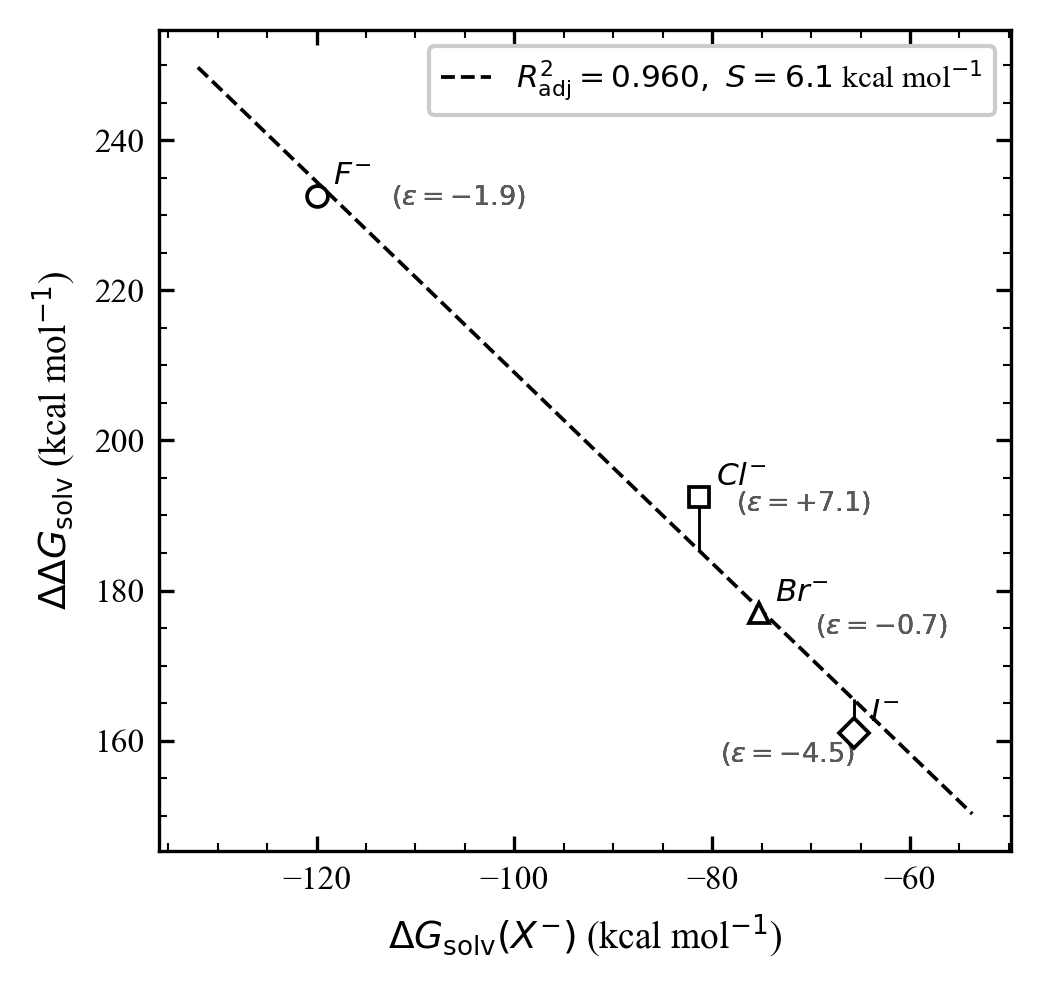

In [19]:
n = len(ddg_solv)

slope, intercept, r_value, p_value, std_err = stats.linregress(dg_solv_x, ddg_solv)
y_pred    = slope * dg_solv_x + intercept
residuals = ddg_solv - y_pred
SSE       = np.sum(residuals**2)
S         = np.sqrt(SSE / (n - 2))                        # regression standard error
R2_adj    = 1 - (1 - r_value**2) * (n - 1) / (n - 2)    # adjusted R²

x_fit = np.linspace(dg_solv_x.min() - 12, dg_solv_x.max() + 12, 300)
y_fit = slope * x_fit + intercept

print(f"slope     = {slope:.4f}")
print(f"intercept = {intercept:.4f}")
print(f"S         = {S:.3f} kcal/mol")
print(f"R2_adj    = {R2_adj:.4f}")
print(f"Residuals = {dict(zip(halogens, residuals.round(2)))}")


fig, ax = plt.subplots(figsize=(3.37, 3.2))

ax.plot(x_fit, y_fit, color='black', lw=0.9, linestyle='--',
        label=(f'$R^{{2}}_{{\\rm adj}}={R2_adj:.3f},\\ '
               f'S={S:.1f}$ kcal mol$^{{-1}}$'))

markers     = ['o', 's', '^', 'D']
res_offsets = [( 6, -11),   # F
               ( 4,   5),   # Cl
               ( 4, -11),   # Br
               (-32, -11)]  # I

for x, y, yp, res, label, mk, off in zip(
        dg_solv_x, ddg_solv, y_pred, residuals, halogens, markers, res_offsets):

    # data point
    ax.plot(x, y, marker=mk, color='black', ms=5, ls='none',
            mfc='white', mew=0.9, zorder=5)

    # vertical residual segment from fit to observation
    ax.vlines(x, yp, y, color='black', lw=0.7, linestyle='-', zorder=4)

    # halogen label
    ax.annotate(f'${label}^{{-}}$', xy=(x, y),
                xytext=(4, 3), textcoords='offset points',
                fontsize=7.5, fontstyle='italic')

    # residual value at midpoint of segment
    sign = '+' if res >= 0 else ''
    # F-
    ax.annotate(r'$(\varepsilon=-1.9)$',
                xy=(-115.0, 237.52),
                xytext=(6, -11), textcoords='offset points',
                fontsize=6.5, color='0.35')

    # Cl-
    ax.annotate(r'$(\varepsilon=+7.1)$',
                xy=(-79.3, 187.87),
                xytext=(4, 5), textcoords='offset points',
                fontsize=6.5, color='0.35')

    # Br-
    ax.annotate(r'$(\varepsilon=-0.7)$',
                xy=(-71.3, 180.33),
                xytext=(4, -11), textcoords='offset points',
                fontsize=6.5, color='0.35')

    # I-
    ax.annotate(r'$(\varepsilon=-4.5)$',
                xy=(-65.7, 163.23),
                xytext=(-32, -11), textcoords='offset points',
                fontsize=6.5, color='0.35')

ax.set_xlabel(r'$\Delta G_{\rm solv}(X^{-})$ (kcal mol$^{-1}$)')
ax.set_ylabel(r'$\Delta\Delta G_{\rm solv}$ (kcal mol$^{-1}$)')
ax.legend(loc='upper right', handlelength=1.6, fontsize=7.5)
ax.grid(False)

plt.tight_layout(pad=0.4)
plt.savefig('ddg_cpl_final.png', dpi=300, bbox_inches='tight')
plt.savefig('ddg_cpl_final.pdf', bbox_inches='tight')
plt.show()

## 4. Regression: ΔΔG_solv vs ΔG_gas — Thermodynamic Compensation Analysis

This cell quantifies the **near-complete cancellation** between the intrinsic
gas-phase stabilization (ΔG_gas < 0) and the hydration-related contribution
(ΔΔG_solv > 0) across the methylmercury halide series.


**What this regression measures:**

A slope of exactly **−1** would mean perfect compensation — every increase in
intrinsic gas-phase stabilization is exactly cancelled by an equal increase in
the hydration penalty, and ΔG_aq would be constant across the series.


**Expected output:**

The dotted reference line (slope = −1) represents exact cancellation.
The dashed regression line shows the observed slight imbalance.

Generates: `fig_ddgsolv_vs_dggas_compensation.pdf` 

  Regression: DDG_solv vs DG_gas^1M
  slope       = -1.1530
  intercept   = -37.8294
  R²          = 0.9999
  R²_adj      = 0.9999
  S           = 0.3556 kcal/mol


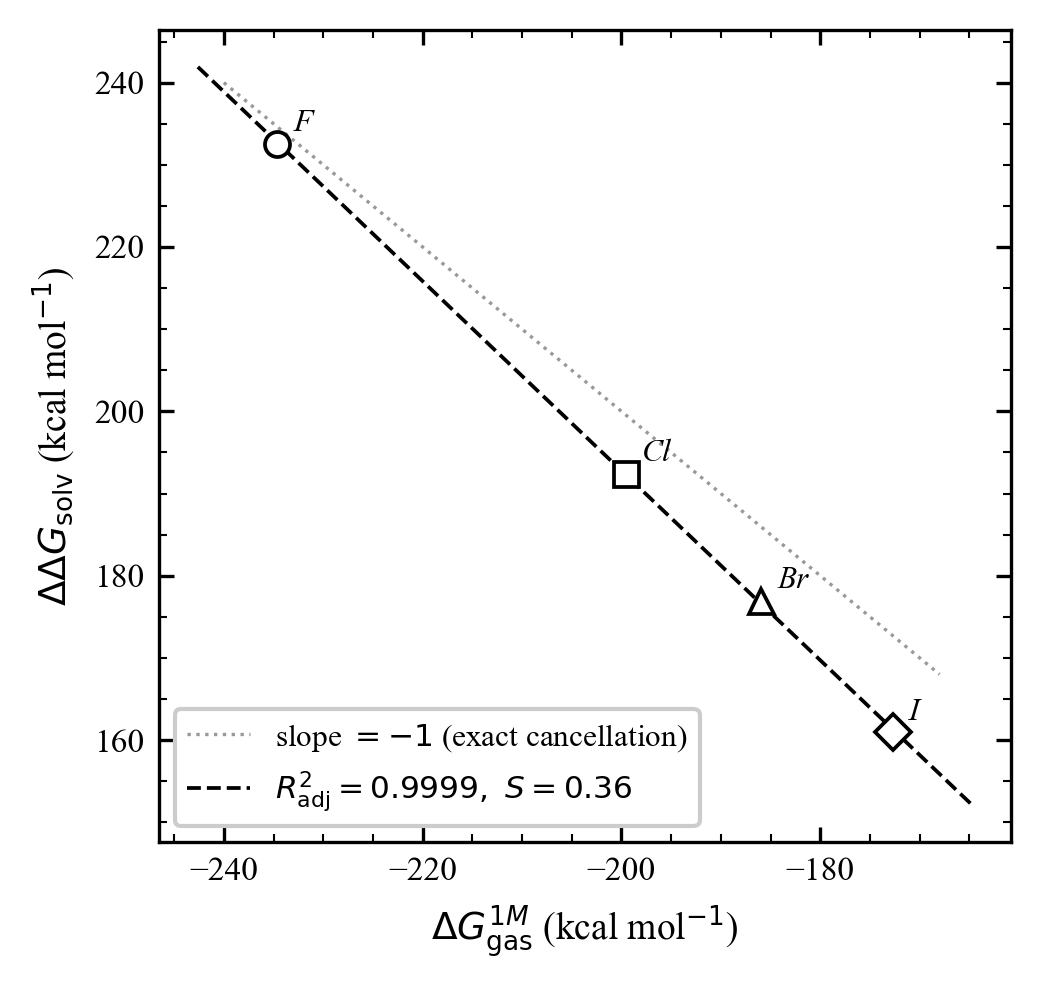

In [20]:
n = len(dg_gas)

slope, intercept, r_value, p_value, std_err = stats.linregress(dg_gas, ddg_solv)
y_pred    = slope * dg_gas + intercept
residuals = ddg_solv - y_pred
SSE       = np.sum(residuals**2)
S         = np.sqrt(SSE / (n - 2))
R2_adj    = 1 - (1 - r_value**2) * (n - 1) / (n - 2)

print("=" * 45)
print("  Regression: DDG_solv vs DG_gas^1M")
print("=" * 45)
print(f"  slope       = {slope:.4f}")
print(f"  intercept   = {intercept:.4f}")
print(f"  R²          = {r_value**2:.4f}")
print(f"  R²_adj      = {R2_adj:.4f}")
print(f"  S           = {S:.4f} kcal/mol")

fig, ax = plt.subplots(figsize=(3.37, 3.2))

markers = ['o', 's', '^', 'D']
for g, s, lab, mk in zip(dg_gas, ddg_solv, halogens, markers):
    ax.plot(g, s, marker=mk, color='black', ms=6,
            mfc='white', mew=0.9, zorder=5)
    ax.annotate(lab, xy=(g, s),
                xytext=(4, 3), textcoords='offset points',
                fontsize=7.5, fontstyle='italic')

# reference line: slope = -1 (exact cancellation, no absolute value)
lims = np.array([-240, -168])
ax.plot(lims, -lims, color='0.6', lw=0.8, ls=':',
        label='slope $= -1$ (exact cancellation)')

# regression line
xfit = np.linspace(dg_gas.min() - 8, dg_gas.max() + 8, 200)
yfit = slope * xfit + intercept
sign = '+' if intercept >= 0 else ''
ax.plot(xfit, yfit, color='black', lw=0.9, ls='--',
        label=(f'$R^{{2}}_{{\\rm adj}}={R2_adj:.4f},\\ S={S:.2f}$'))

ax.set_xlabel(r'$\Delta G_{\rm gas}^{1M}$ (kcal mol$^{-1}$)')
ax.set_ylabel(r'$\Delta\Delta G_{\rm solv}$ (kcal mol$^{-1}$)')
ax.legend(fontsize=7.5, loc='lower left')
ax.grid(False)

plt.tight_layout(pad=0.4)
plt.savefig('fig_ddgsolv_vs_dggas_compensation.png', dpi=300, bbox_inches='tight')
plt.savefig('fig_ddgsolv_vs_dggas_compensation.pdf', bbox_inches='tight')
plt.show()



---
## 5. Regression 3 — ΔG_aq vs ΔG_solv(X⁻)

This is the central result of the paper: the **final aqueous association free energy 
depends linearly on the hydration free energy of the free halide**, with a small 
slope (−0.168) that directly reflects the near-cancellation between gas-phase 
and solvation contributions.

Two lines are shown:  
- **Direct regression** on experimental data (solid line)  
- **Analytical prediction** derived from combining Regressions 1 and 2 (dotted line)

Generates: `fig_dgaq_vs_dgsolv_exp.pdf` → **Figure 4** of the manuscript.


LINEAR REGRESSION: DG_aq vs DG_solv(X-)
Slope                  = -0.167819
Intercept              = -21.853610
Equation               = DG_aq = -0.168 * DG_solv(X-) -21.85
R²                     =  0.958782
Adjusted R²            =  0.938173
Residual std. error S  =  1.015637 kcal/mol

Residuals
F : observed = -2.050, fitted = -1.715, residual = -0.335
Cl: observed = -7.160, fitted = -8.210, residual = +1.050
Br: observed = -9.030, fitted = -9.217, residual = +0.187
I : observed = -11.730, fitted = -10.828, residual = -0.902


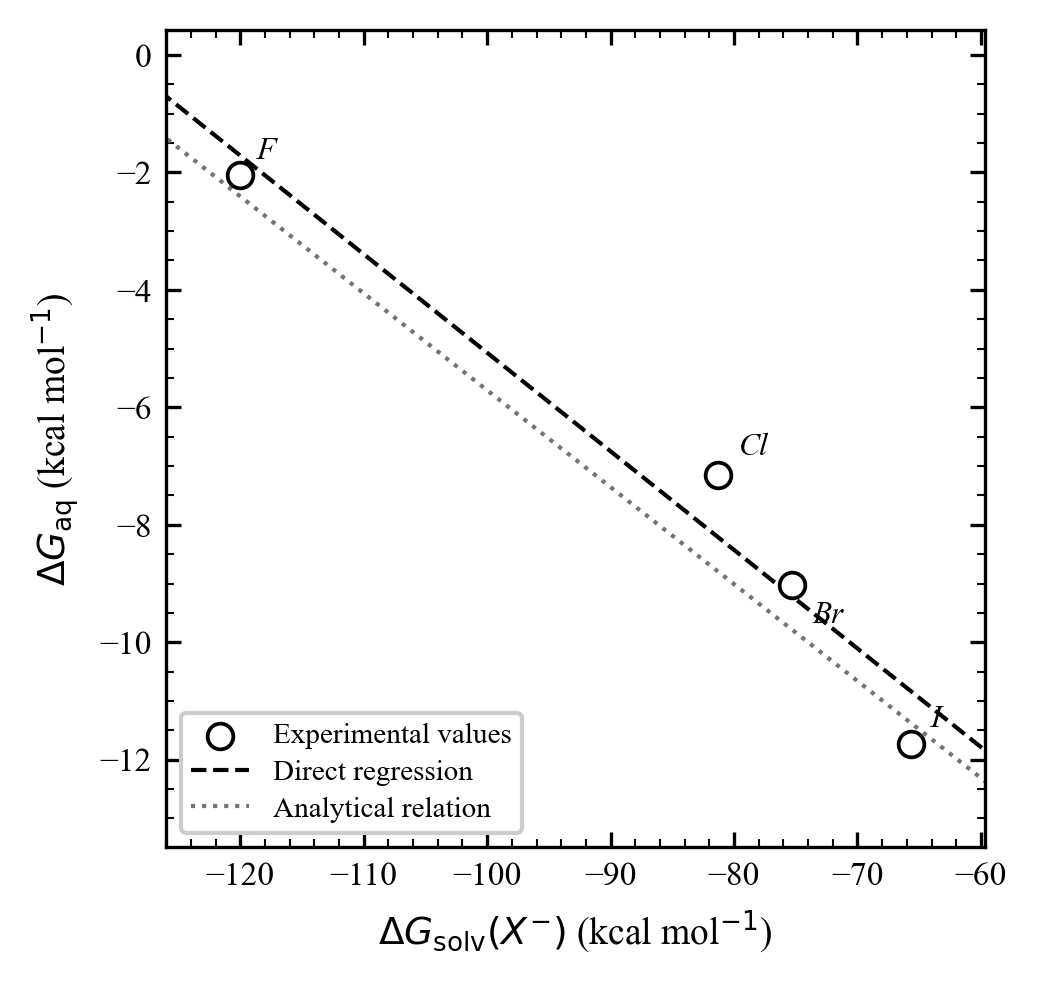

In [21]:
n = len(dg_solv_x)

slope, intercept, r_value, p_value, slope_se = stats.linregress(
    dg_solv_x,
    dg_aq_ref
)

# Predictions and residuals
y_pred_reg = slope * dg_solv_x + intercept
residuals = dg_aq_ref - y_pred_reg

# Regression statistics
SSE = np.sum(residuals**2)
MSE = SSE / (n - 2)
S = np.sqrt(MSE)  # residual standard error
RMSE = np.sqrt(np.mean(residuals**2))

R2 = r_value**2
R2_adj = 1 - (1 - R2) * (n - 1) / (n - 2)

# 95% confidence intervals
t95 = stats.t.ppf(0.975, df=n - 2)

x_mean = np.mean(dg_solv_x)
SSx = np.sum((dg_solv_x - x_mean) ** 2)

intercept_se = np.sqrt(
    MSE * (1 / n + x_mean**2 / SSx)
)

slope_ci = (
    slope - t95 * slope_se,
    slope + t95 * slope_se
)

intercept_ci = (
    intercept - t95 * intercept_se,
    intercept + t95 * intercept_se
)

# =========================================================
# Print statistics
# =========================================================
print("\n" + "=" * 72)
print("LINEAR REGRESSION: DG_aq vs DG_solv(X-)")
print("=" * 72)
print(f"Slope                  = {slope: .6f}")
print(f"Intercept              = {intercept: .6f}")
print(f"Equation               = DG_aq = {slope:.3f} * DG_solv(X-) {intercept:+.2f}")
print(f"R²                     = {R2: .6f}")
print(f"Adjusted R²            = {R2_adj: .6f}")
print(f"Residual std. error S  = {S: .6f} kcal/mol")

print("\nResiduals")
for hal, obs, pred, res in zip(["F", "Cl", "Br", "I"], dg_aq_ref, y_pred_reg, residuals):
    print(f"{hal:2s}: observed = {obs: .3f}, fitted = {pred: .3f}, residual = {res:+.3f}")

print("=" * 72)


analytical_slope = -0.165
analytical_intercept = -22.21


xfit = np.linspace(dg_solv_x.min() - 8, dg_solv_x.max() + 8, 300)

# Direct regression on observed aqueous values
yfit_reg = slope * xfit + intercept

# Analytical relation derived from thermodynamic cycle
yfit_analytical = analytical_slope * xfit + analytical_intercept


fig, ax = plt.subplots(figsize=(3.37, 3.20))

# Scatter: observed thermodynamic-cycle values
ax.scatter(
    dg_solv_x,
    dg_aq_ref,
    s=38,
    facecolors="white",
    edgecolors="black",
    linewidths=0.9,
    zorder=5,
    label="Experimental values"
)

# Point labels
offsets = {
    "F": (4, 4),
    "Cl": (5, 5),
    "Br": (5, -9),
    "I": (5, 4),
}

for x, y, lab in zip(dg_solv_x, dg_aq_ref, halogens):
    dx, dy = offsets[lab]
    ax.annotate(
        lab,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=7.5,
        fontstyle="italic",
    )

# Direct regression line
ax.plot(
    xfit,
    yfit_reg,
    color="black",
    lw=1.0,
    ls="--",
    label="Direct regression",
    zorder=3,
)

# Analytical relation line
ax.plot(
    xfit,
    yfit_analytical,
    color="0.45",
    lw=1.0,
    ls=":",
    label="Analytical relation",
    zorder=2,
)

# Axis labels
ax.set_xlabel(r"$\Delta G_{\rm solv}(X^{-})$ (kcal mol$^{-1}$)")
ax.set_ylabel(r"$\Delta G_{\rm aq}$ (kcal mol$^{-1}$)")

# Limits
ax.set_xlim(dg_solv_x.min() - 6, dg_solv_x.max() + 6)

y_min = min(dg_aq_ref.min(), yfit_reg.min(), yfit_analytical.min())
y_max = max(dg_aq_ref.max(), yfit_reg.max(), yfit_analytical.max())
ax.set_ylim(y_min - 0.8, y_max + 0.8)

# Legend
ax.legend(
    loc="lower left",
    fontsize=7.0,
    handlelength=2.0,
    borderpad=0.35,
    labelspacing=0.35,
)

ax.grid(False)

plt.tight_layout(pad=0.45)

plt.savefig("fig_dgaq_vs_dgsolv_exp.png", dpi=300, bbox_inches="tight")
plt.savefig("fig_dgaq_vs_dgsolv_exp.pdf", bbox_inches="tight")

plt.show()

## Regression: ΔG_solv(CH₃HgX) vs ΔG_solv(X⁻) — Solvation Attenuation Analysis

This cell quantifies the **attenuation of halide-dependent hydration upon
coordination to CH₃Hg⁺**. It is one of the central mechanistic results of
the paper: the neutral CH₃HgX complexes are far less sensitive to halide
identity than the free anions.

Generates: `fig_ch3hgx_solv_vs_halide_solv.pdf` 


Slope                  =  0.103101
Intercept              =  2.116434
Equation               = DG_solv(CH3HgX) = 0.103 * DG_solv(X-) +2.12

Fit quality
R²                     =  0.923610
Adjusted R²            =  0.847220
Residual std. error S  =  0.329964 kcal/mol

Residuals
Cl: observed = -6.430, fitted = -6.266, residual = -0.164
Br: observed = -5.380, fitted = -5.647, residual = +0.267
I : observed = -4.760, fitted = -4.657, residual = -0.103


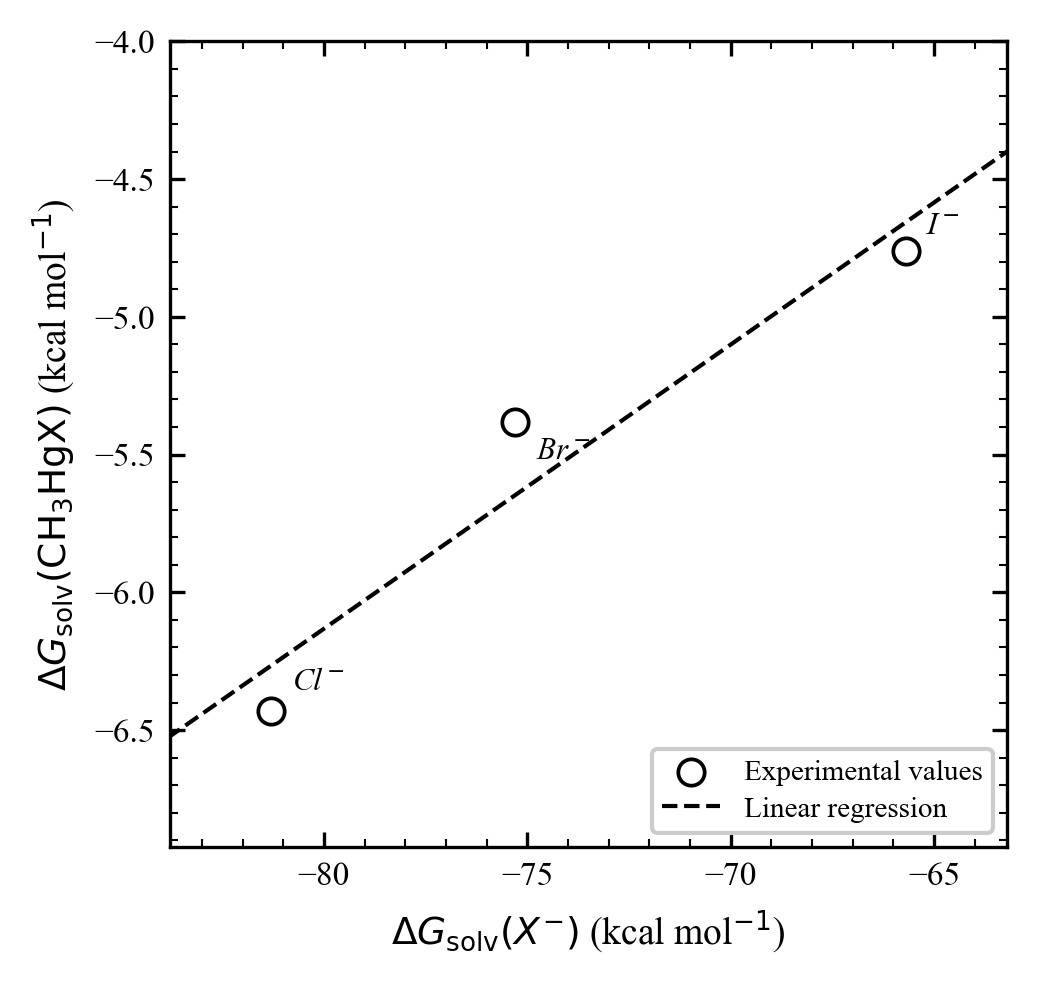

In [22]:
halides = ["Cl$^-$", "Br$^-$", "I$^-$"]

# x-axis: experimental hydration free energy of free halide anion
dg_solv_x = np.array([-81.3, -75.3, -65.7])

# y-axis: experimental solvation free energy of neutral CH3HgX
dg_solv_ch3hgx = np.array([-6.43, -5.38, -4.76])


n = len(dg_solv_x)


slope, intercept, r_value, p_value, slope_se = stats.linregress(
    dg_solv_x,
    dg_solv_ch3hgx
)

y_fit_points = slope * dg_solv_x + intercept
residuals = dg_solv_ch3hgx - y_fit_points

SSE = np.sum(residuals**2)
MSE = SSE / (n - 2)
S = np.sqrt(MSE)
RMSE = np.sqrt(np.mean(residuals**2))

R2 = r_value**2

# Adjusted R2 is weakly informative for n=3, but included for completeness
R2_adj = 1 - (1 - R2) * (n - 1) / (n - 2)

# 95% confidence intervals
# Note: with n=3, df=1, intervals will be very wide
t95 = stats.t.ppf(0.975, df=n - 2)

x_mean = np.mean(dg_solv_x)
SSx = np.sum((dg_solv_x - x_mean) ** 2)

intercept_se = np.sqrt(
    MSE * (1 / n + x_mean**2 / SSx)
)

slope_ci = (
    slope - t95 * slope_se,
    slope + t95 * slope_se
)

intercept_ci = (
    intercept - t95 * intercept_se,
    intercept + t95 * intercept_se
)

print(f"Slope                  = {slope: .6f}")
print(f"Intercept              = {intercept: .6f}")
print(
    f"Equation               = DG_solv(CH3HgX) = "
    f"{slope:.3f} * DG_solv(X-) {intercept:+.2f}"
)

print("\nFit quality")
print(f"R²                     = {R2: .6f}")
print(f"Adjusted R²            = {R2_adj: .6f}")
print(f"Residual std. error S  = {S: .6f} kcal/mol")

print("\nResiduals")
for hal, obs, pred, res in zip(["Cl", "Br", "I"], dg_solv_ch3hgx, y_fit_points, residuals):
    print(f"{hal:2s}: observed = {obs: .3f}, fitted = {pred: .3f}, residual = {res:+.3f}")

print("=" * 78)


xfit = np.linspace(dg_solv_x.min() - 3, dg_solv_x.max() + 3, 300)
yfit = slope * xfit + intercept

fig, ax = plt.subplots(figsize=(3.37, 3.20))

# Scatter points
ax.scatter(
    dg_solv_x,
    dg_solv_ch3hgx,
    s=40,
    facecolors="white",
    edgecolors="black",
    linewidths=0.9,
    zorder=5,
    label="Experimental values"
)

# Point labels
offsets = {
    "Cl$^-$": (5, 5),
    "Br$^-$": (5, -9),
    "I$^-$": (5, 4),
}

for x, y, lab in zip(dg_solv_x, dg_solv_ch3hgx, halides):
    dx, dy = offsets[lab]
    ax.annotate(
        lab,
        xy=(x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        fontsize=7.5,
        fontstyle="italic",
    )

# Regression line
ax.plot(
    xfit,
    yfit,
    color="black",
    lw=1.0,
    ls="--",
    label="Linear regression",
    zorder=3,
)

# Axis labels
ax.set_xlabel(r"$\Delta G_{\rm solv}(X^{-})$ (kcal mol$^{-1}$)")
ax.set_ylabel(r"$\Delta G_{\rm solv}({\rm CH_3HgX})$ (kcal mol$^{-1}$)")

# Limits
ax.set_xlim(dg_solv_x.min() - 2.5, dg_solv_x.max() + 2.5)

y_min = min(dg_solv_ch3hgx.min(), yfit.min())
y_max = max(dg_solv_ch3hgx.max(), yfit.max())
ax.set_ylim(y_min - 0.35, y_max + 0.35)

# Legend
ax.legend(
    loc="lower right",
    fontsize=7.0,
    handlelength=2.0,
    borderpad=0.35,
    labelspacing=0.35,
)

ax.grid(False)

plt.tight_layout(pad=0.45)

plt.savefig("fig_ch3hgx_solv_vs_halide_solv.png", dpi=300, bbox_inches="tight")
plt.savefig("fig_ch3hgx_solv_vs_halide_solv.pdf", bbox_inches="tight")

plt.show()

---
## 6. Graphical abstract - Thermodynamic Cycle Diagram

Schematic representation of the Born–Haber-type thermodynamic cycle used to 
decompose ΔG_aq into its gas-phase and solvation components:

$$\Delta G_{\rm aq} = \Delta G_{\rm gas}^{1M} + \Delta\Delta G_{\rm solv}$$

where:
- Horizontal arrows represent association reactions (gas phase top, aqueous bottom)
- Vertical dashed arrows represent solvation free energies of each species

Generates: `graphical_abstract.pdf` 

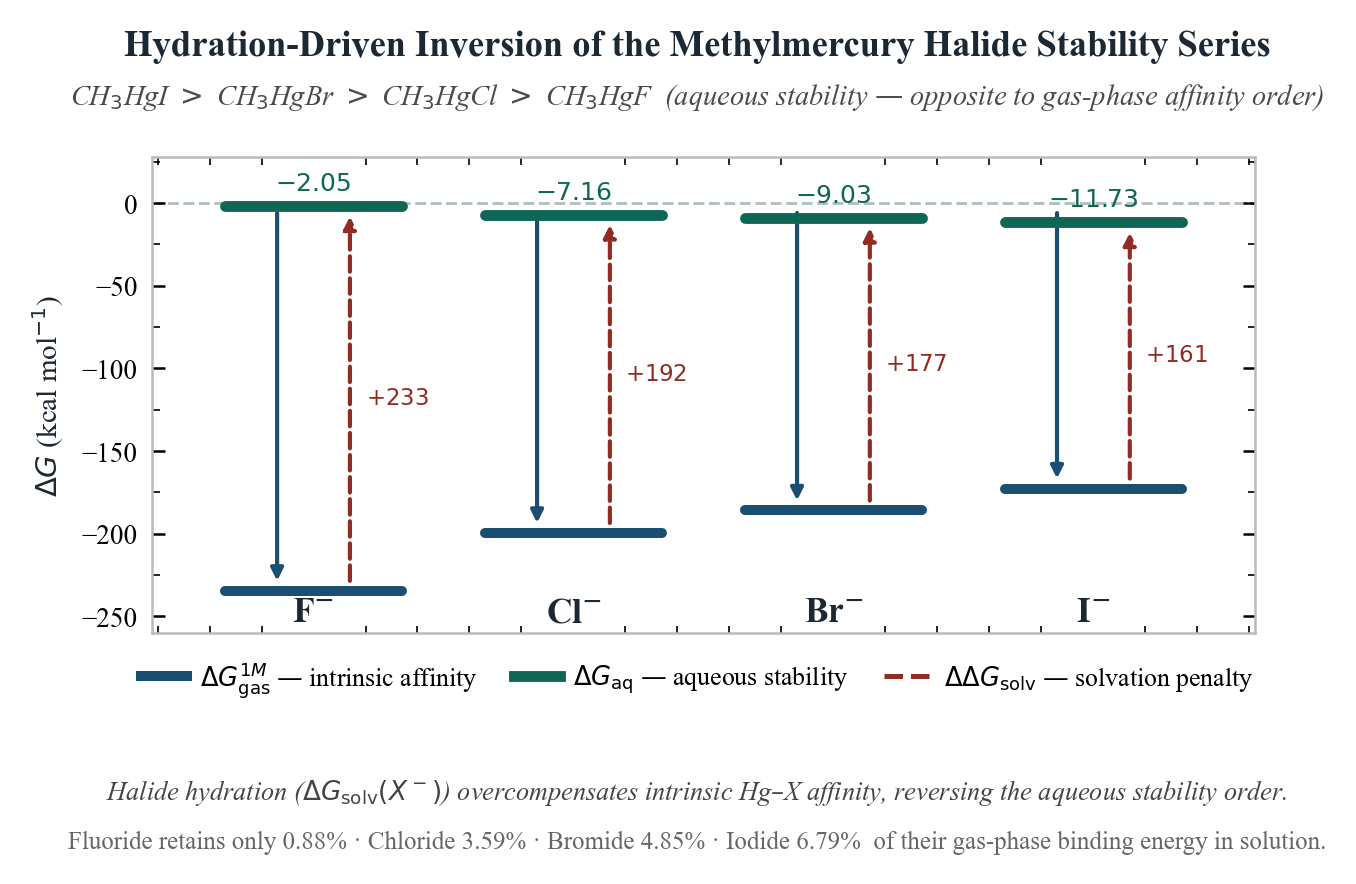

In [23]:
DPI  = 300
W_PX = 1328
H_PX = 850 #531
W_IN = W_PX / DPI
H_IN = H_PX / DPI

mpl.rcParams.update({
    "font.family":          "serif",
    "font.serif":           ["Times New Roman", "DejaVu Serif"],
    "font.size":            7.0,
    "axes.labelsize":       7.0,
    "xtick.labelsize":      6.5,
    "ytick.labelsize":      6.5,
    "figure.dpi":           DPI,
    "axes.linewidth":       0.6,
    "xtick.major.width":    0.6,
    "ytick.major.width":    0.6,
    "xtick.minor.width":    0.4,
    "ytick.minor.width":    0.4,
    "xtick.direction":      "in",
    "ytick.direction":      "in",
    "xtick.minor.visible":  True,
    "ytick.minor.visible":  True,
    "xtick.top":            True,
    "ytick.right":          True,
    "xtick.major.size":     3.0,
    "ytick.major.size":     3.0,
    "xtick.minor.size":     1.8,
    "ytick.minor.size":     1.8,
    "legend.frameon":       False,
    "legend.borderpad":     0.4,
    "legend.labelspacing":  0.3,
    "legend.handlelength":  1.8,
})

C_GAS   = "#1B4F72"
C_AQ    = "#0E6655"
C_SOLV  = "#922B21"
C_ZERO  = "#95A5A6"
C_LABEL = "#1C2833"
C_BG    = "#FFFFFF"

halogens = ["F$^{-}$", "Cl$^{-}$", "Br$^{-}$", "I$^{-}$"]
dg_gas   = np.array([-234.61, -199.59, -186.00, -172.71])
dg_aq    = np.array([  -2.05,   -7.16,   -9.03,  -11.73])
ddg_solv = dg_aq - dg_gas

fig = plt.figure(figsize=(W_IN, H_IN), facecolor=C_BG)

# Axes: generous vertical space, centered horizontally
ax = fig.add_axes([0.09, 0.28, 0.83, 0.56])
ax.set_facecolor(C_BG)
for spine in ax.spines.values():
    spine.set_linewidth(0.6)
    spine.set_color("#BBBBBB")


fig.text(
    0.50, 0.990,
    "Hydration-Driven Inversion of the Methylmercury Halide Stability Series",
    ha="center", va="top",
    fontsize=8.8, fontweight="bold", color=C_LABEL, fontfamily="serif",
)
# gap
fig.text(
    0.50, 0.928,
    r"CH$_3$HgI $>$ CH$_3$HgBr $>$ CH$_3$HgCl $>$ CH$_3$HgF  "
    r"(aqueous stability — opposite to gas-phase affinity order)",
    ha="center", va="top",
    fontsize=6.8, color="#4A4A4A", fontstyle="italic", fontfamily="serif",
)


x  = np.arange(4)
bw = 0.34

ax.set_ylim(-260, 28)
ax.set_xlim(-0.62, 3.62)
ax.axhline(0, color=C_ZERO, lw=0.7, ls="--", zorder=1, alpha=0.7)

for i, (gas, aq, sol, lab) in enumerate(
        zip(dg_gas, dg_aq, ddg_solv, halogens)):
    xi = float(x[i])

    ax.plot([xi - bw, xi + bw], [gas, gas],
            color=C_GAS, lw=2.4, zorder=4, solid_capstyle="round")
    ax.plot([xi - bw, xi + bw], [aq, aq],
            color=C_AQ,  lw=2.6, zorder=4, solid_capstyle="round")

    # arrow: 0 → gas (association)
    ax.annotate("",
        xy=(xi - 0.14, gas + 1), xytext=(xi - 0.14, -1),
        arrowprops=dict(arrowstyle="-|>", color=C_GAS,
                        lw=1.0, mutation_scale=6), zorder=3)

    # arrow: gas → aq (solvation penalty)
    ax.annotate("",
        xy=(xi + 0.14, aq - 1), xytext=(xi + 0.14, gas + 1),
        arrowprops=dict(arrowstyle="-|>", color=C_SOLV,
                        lw=1.0, mutation_scale=6,
                        linestyle="dashed"), zorder=3)

    # ΔG_aq value above aqueous bar
    ax.text(xi, aq + 6.5, rf"${aq:.2f}$",
            ha="center", va="bottom", fontsize=6.0,
            color=C_AQ, fontweight="bold")

    # ΔΔG_solv beside penalty arrow
    ax.text(xi + 0.20, (gas + aq) / 2, rf"$+{sol:.0f}$",
            ha="left", va="center", fontsize=5.5, color=C_SOLV)

    # halide label below axis
    ax.text(xi, -258, lab,
            ha="center", va="bottom",
            fontsize=8.5, fontweight="bold", color=C_LABEL,
            fontfamily="serif")


ax.set_xticks(x)
ax.set_xticklabels([""] * 4)
ax.set_ylabel(r"$\Delta G$ (kcal mol$^{-1}$)",
              fontsize=7.0, color=C_LABEL, labelpad=4)
ax.yaxis.set_major_locator(mpl.ticker.MultipleLocator(50))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(25))
ax.tick_params(axis="x", bottom=False, top=False)
ax.grid(False)


handles = [
    Line2D([0],[0], color=C_GAS,  lw=2.4,
           label=r"$\Delta G_{\rm gas}^{1M}$ — intrinsic affinity"),
    Line2D([0],[0], color=C_AQ,   lw=2.6,
           label=r"$\Delta G_{\rm aq}$ — aqueous stability"),
    Line2D([0],[0], color=C_SOLV, lw=1.2, ls="--",
           label=r"$\Delta\Delta G_{\rm solv}$ — solvation penalty"),
]
fig.legend(
    handles=handles,
    loc="lower center",
    bbox_to_anchor=(0.50, 0.175),   # centered, below axes
    ncol=3,
    fontsize=6.2,
    handlelength=1.8,
    handletextpad=0.5,
    columnspacing=1.4,
    frameon=False,
)


fig.text(
    0.50, 0.110,
    r"Halide hydration ($\Delta G_{\rm solv}(X^-)$) overcompensates "
    r"intrinsic Hg–X affinity, reversing the aqueous stability order.",
    ha="center", va="top",
    fontsize=6.3, color="#444444", fontstyle="italic", fontfamily="serif",
)
fig.text(
    0.50, 0.048,
    r"Fluoride retains only 0.88% · Chloride 3.59% · "
    r"Bromide 4.85% · Iodide 6.79%  of their gas-phase binding energy in solution.",
    ha="center", va="top",
    fontsize=6.0, color="#666666", fontfamily="serif",
)


plt.savefig("graphical_abstract.png", dpi=DPI,
            bbox_inches="tight", facecolor=C_BG)
plt.savefig("graphical_abstract.pdf",
            bbox_inches="tight", facecolor=C_BG)
plt.show()
